In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

#Dataset

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("muhammadwaqas023/predictive-maintenance-oil-and-gas-pipeline-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'predictive-maintenance-oil-and-gas-pipeline-data' dataset.
Path to dataset files: /kaggle/input/predictive-maintenance-oil-and-gas-pipeline-data


visualizando as 5 primeiras linhas do dataset

In [3]:
import os
dataset_filename = 'market_pipe_thickness_loss_dataset.csv'

dataset_full_path = os.path.join(path, dataset_filename)

df = pd.read_csv(dataset_full_path)

print(df.head())

   Pipe_Size_mm  Thickness_mm      Material              Grade  \
0           800         15.48  Carbon Steel  ASTM A333 Grade 6   
1           800         22.00           PVC  ASTM A106 Grade B   
2           400         12.05  Carbon Steel         API 5L X52   
3          1500         38.72  Carbon Steel         API 5L X42   
4          1500         24.32          HDPE         API 5L X65   

   Max_Pressure_psi  Temperature_C  Corrosion_Impact_Percent  \
0               300           84.9                     16.04   
1               150           14.1                      7.38   
2              2500            0.6                      2.12   
3              1500           52.7                      5.58   
4              1500           11.7                     12.29   

   Thickness_Loss_mm  Material_Loss_Percent  Time_Years Condition  
0               4.91                  31.72           2  Moderate  
1               7.32                  33.27           4  Critical  
2             

Verificação das dimensões e formatos dos dados

In [4]:
print("Dimensões:", df.shape)
print("\nColunas:")
print(df.columns)
print("\nTipos de dados:")
print(df.dtypes)

Dimensões: (1000, 11)

Colunas:
Index(['Pipe_Size_mm', 'Thickness_mm', 'Material', 'Grade', 'Max_Pressure_psi',
       'Temperature_C', 'Corrosion_Impact_Percent', 'Thickness_Loss_mm',
       'Material_Loss_Percent', 'Time_Years', 'Condition'],
      dtype='object')

Tipos de dados:
Pipe_Size_mm                  int64
Thickness_mm                float64
Material                     object
Grade                        object
Max_Pressure_psi              int64
Temperature_C               float64
Corrosion_Impact_Percent    float64
Thickness_Loss_mm           float64
Material_Loss_Percent       float64
Time_Years                    int64
Condition                    object
dtype: object


Verificando de dados faltantes

In [5]:
print(df.isnull().sum())

Pipe_Size_mm                0
Thickness_mm                0
Material                    0
Grade                       0
Max_Pressure_psi            0
Temperature_C               0
Corrosion_Impact_Percent    0
Thickness_Loss_mm           0
Material_Loss_Percent       0
Time_Years                  0
Condition                   0
dtype: int64


Verificando a distribuição das condições dos canos

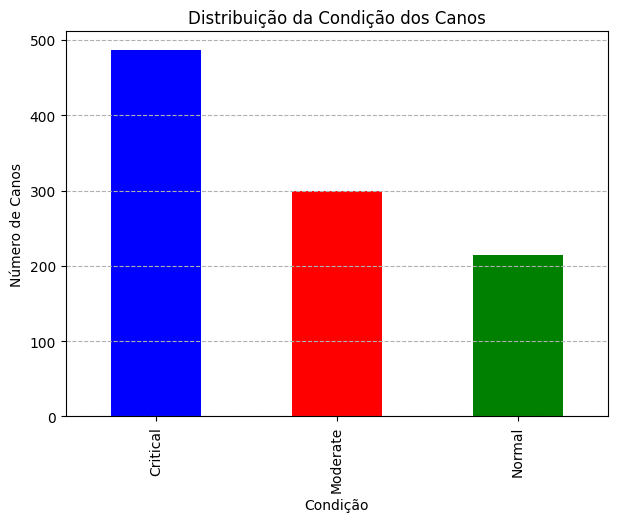

In [6]:
plt.figure(figsize=(7, 5))
condition_counts = df['Condition'].value_counts()
condition_counts.plot(kind='bar', color=['blue', 'red', 'green'])
plt.title('Distribuição da Condição dos Canos')
plt.xlabel('Condição')
plt.ylabel('Número de Canos')
plt.grid(axis='y', linestyle='--')
plt.show()

Preparação dos dados de entrada

In [7]:
caracteristicas = df.drop('Condition', axis=1)
encoder_categoricas = OneHotEncoder(sparse_output=False,)

categoricas_encoded = encoder_categoricas.fit_transform(caracteristicas[['Material', 'Grade']])
numericas = caracteristicas.drop(['Material', 'Grade'],axis=1).values
# Juntando características numéricas + categóricas
caracteristicas_encoded = np.hstack([numericas,categoricas_encoded])

print("Formato das entradas:", caracteristicas_encoded.shape)

Formato das entradas: (1000, 18)


Preparação dos dados de saída

In [8]:
# One-Hot Encoding das classes de saída
condicoes = df['Condition']
encoder_condicao = OneHotEncoder(sparse_output=False)

condicoes_encoded = encoder_condicao.fit_transform(
    condicoes.values.reshape(-1, 1)
)

print("Classes:", encoder_condicao.categories_)
print(condicoes_encoded[:5])

Classes: [array(['Critical', 'Moderate', 'Normal'], dtype=object)]
[[0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


Criando a divisão de treino

In [9]:
caract_treino, caract_teste, cond_treino, cond_teste = train_test_split(
    caracteristicas_encoded, condicoes_encoded, test_size=0.20, random_state=42, stratify=condicoes
)

print("Dados de treino:", caract_treino.shape)
print("Dados de teste:", caract_teste.shape)

Dados de treino: (800, 18)
Dados de teste: (200, 18)


Padronização dos dados para terem a mesma escala em treino e teste

In [10]:
padronizador = StandardScaler()

caract_treino = padronizador.fit_transform(caract_treino)
caract_teste = padronizador.transform(caract_teste)


In [11]:
numero_entradas = caract_treino.shape[1]
print(numero_entradas)

18


In [12]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(18,)),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │           190 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 223 (892.00 B)

 Trainable params: 223 (892.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

historico = model.fit(caract_treino, cond_treino, epochs=100, batch_size=5, validation_split=0.1)

Epoch 1/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.5708 - loss: 0.9611 - val_accuracy: 0.5750 - val_loss: 0.8874
Epoch 2/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6444 - loss: 0.7838 - val_accuracy: 0.6500 - val_loss: 0.7402
Epoch 3/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7250 - loss: 0.6602 - val_accuracy: 0.7500 - val_loss: 0.6330
Epoch 4/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7764 - loss: 0.5670 - val_accuracy: 0.7875 - val_loss: 0.5525
Epoch 5/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8153 - loss: 0.4974 - val_accuracy: 0.8125 - val_loss: 0.4926
Epoch 6/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8361 - loss: 0.4429 - val_accuracy: 0.8375 - val_loss: 0.4459
Epoch 7/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8431 - loss: 0.3994 - val_accuracy: 0.8375 - val_loss: 0.4062
Epoch 8/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8667 - loss: 0.3634 - val_acc

In [22]:
model.save("oilgas.keras")

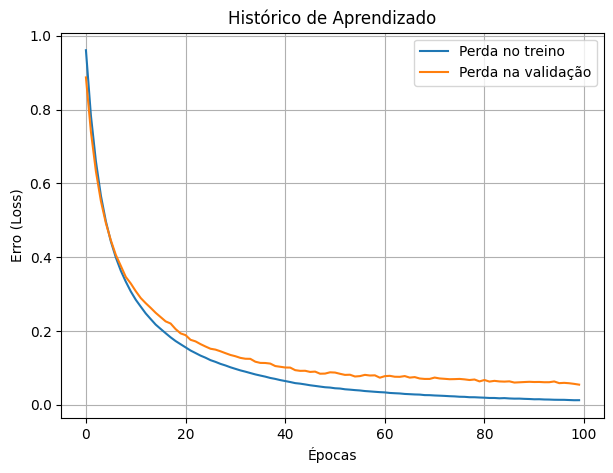

In [14]:
plt.figure(figsize=(7, 5))
plt.plot(historico.history['loss'],label='Perda no treino')
plt.plot(historico.history['val_loss'],label='Perda na validação')
plt.title('Histórico de Aprendizado')
plt.xlabel('Épocas')
plt.ylabel('Erro (Loss)')
plt.legend()
plt.grid(True)
plt.show()

#Resultados

In [15]:
# Recupera os nomes das colunas categóricas codificadas
nomes_categoricas = encoder_categoricas.get_feature_names_out(['Material', 'Grade'])

# Pega o nome das colunas numéricas
nomes_numericas = caracteristicas.drop(['Material', 'Grade'], axis=1).columns.tolist()

# Junta tudo para formar a lista completa com 18 nomes
nomes_caracteristicas_completo = list(nomes_numericas) + list(nomes_categoricas)
print(nomes_caracteristicas_completo)

['Pipe_Size_mm', 'Thickness_mm', 'Max_Pressure_psi', 'Temperature_C', 'Corrosion_Impact_Percent', 'Thickness_Loss_mm', 'Material_Loss_Percent', 'Time_Years', 'Material_Carbon Steel', 'Material_Fiberglass', 'Material_HDPE', 'Material_PVC', 'Material_Stainless Steel', 'Grade_API 5L X42', 'Grade_API 5L X52', 'Grade_API 5L X65', 'Grade_ASTM A106 Grade B', 'Grade_ASTM A333 Grade 6']


In [16]:

previsoes = model.predict(caract_teste)
classes_preditas = np.argmax(previsoes, axis=1)
respostas = np.argmax(cond_teste, axis=1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


Métricas de avaliação do modelo

In [17]:

print("acurácia:",accuracy_score(respostas, classes_preditas))
resultados = classification_report(respostas, classes_preditas)
print(resultados)

acurácia: 0.945
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        97
           1       0.89      0.93      0.91        60
           2       0.90      0.86      0.88        43

    accuracy                           0.94       200
   macro avg       0.93      0.93      0.93       200
weighted avg       0.95      0.94      0.95       200



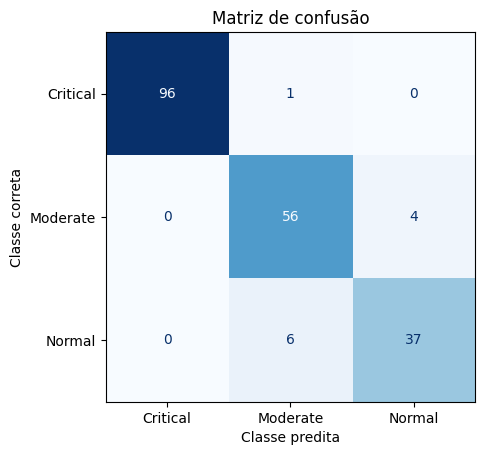

In [18]:
labels = np.unique(condicoes)
matriz = confusion_matrix(respostas, classes_preditas)
display = ConfusionMatrixDisplay(matriz, display_labels=labels)
display.plot(cmap='Blues',colorbar=False)
plt.ylabel("Classe correta")
plt.xlabel("Classe predita")
display.ax_.set_title("Matriz de confusão")
plt.show()

Ia explicável

In [19]:
!pip install shap

In [20]:
import shap
explainer = shap.KernelExplainer(model.predict, caract_teste[:50])
shap_values = explainer.shap_values(caract_teste)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step


  0%|          | 0/200 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
3257/3257 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step
3257/3257 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
3257/3257 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
3257/3257 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
3257/3257 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
3257/3257 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
3257/3257 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
3257/3257 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
3257/3257 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
3257/3257 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
3257/3257 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
3257/3257 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

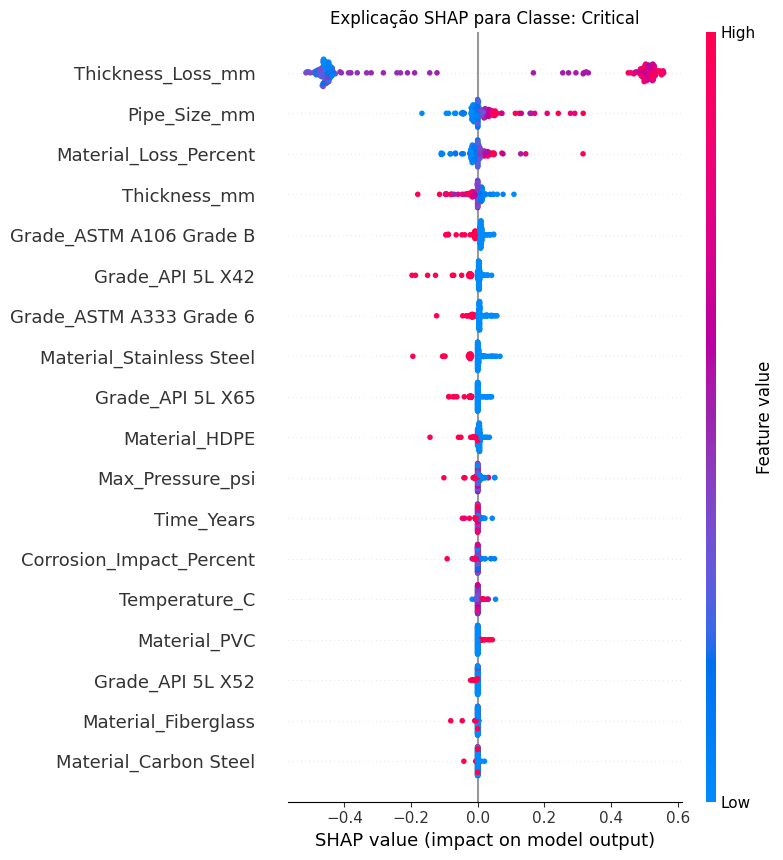

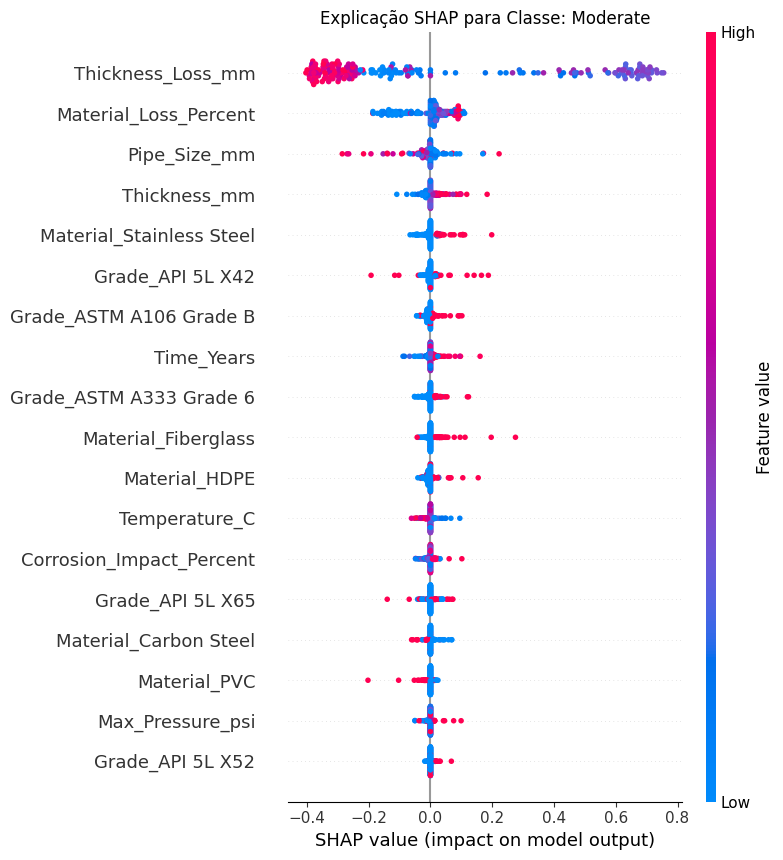

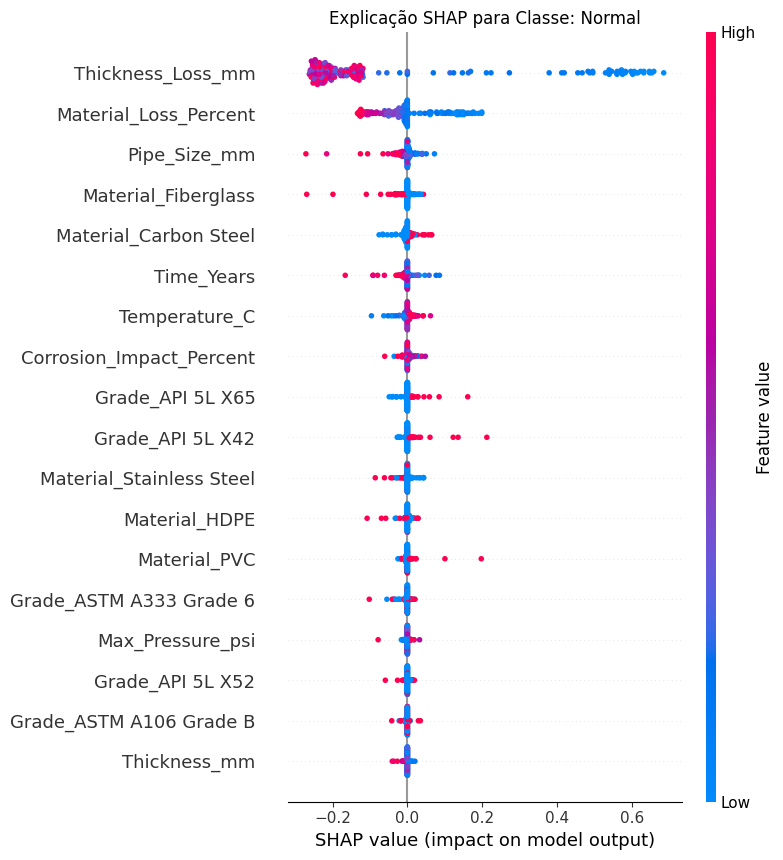

In [21]:
for i, label in enumerate(labels):
    plt.figure(figsize=(6,3))
    plt.title(f"Explicação SHAP para Classe: {label}")
    shap_val_class = shap_values[:, :, i]
    shap.summary_plot(shap_val_class, caract_teste, feature_names=nomes_caracteristicas_completo)
    plt.show()